# A simple project so that you can Practice Linear Regression

This is a very simple project and the data set is also very simple to understnad, so all the knowledge you gained from the previous articles will be enough for this project.

- First import the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

- Now Load the `Ecommerce Customers` from this folder.

In [4]:
data = pd.read_csv('Ecommerce Customers.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Ecommerce Customers.csv'

- Get the informations about the data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


It has 500 samples and 8 features. 

- Now, see the head of the data.

In [ ]:
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


Now let's do some exploratory data analysis.

- Make a pairplot of the whole data.

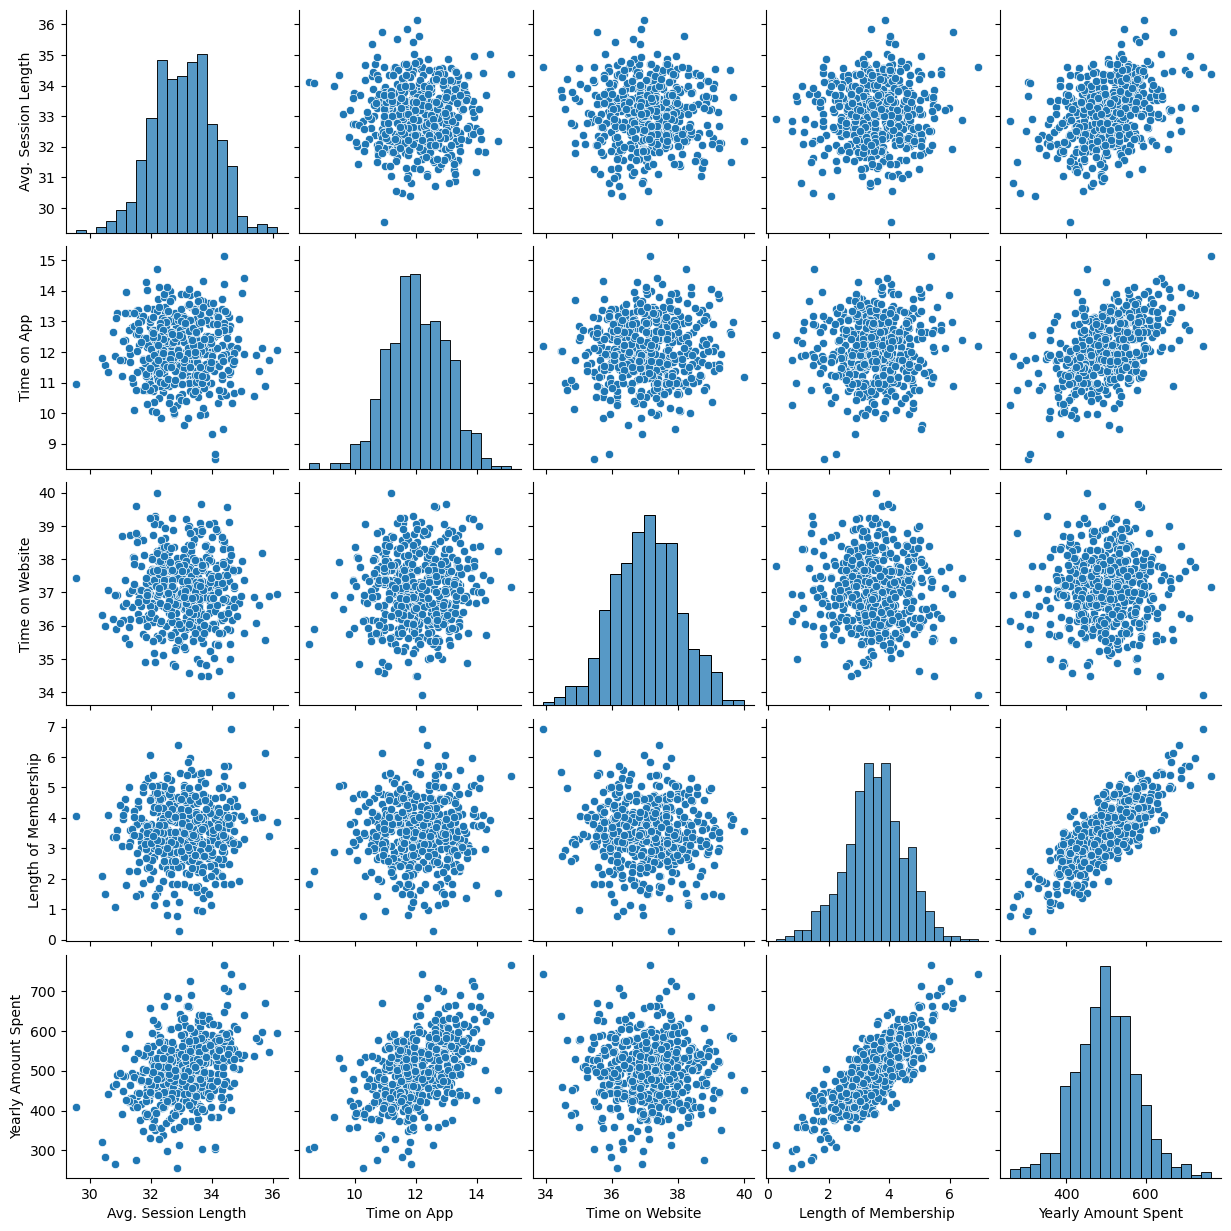

In [ ]:
sns.pairplot(data)

- Try to find the most correlated features from the pairplot and see which should be the `target` feature.

> Make a jointplot and lmplot to visualise the relationship between those two features in the cell below.

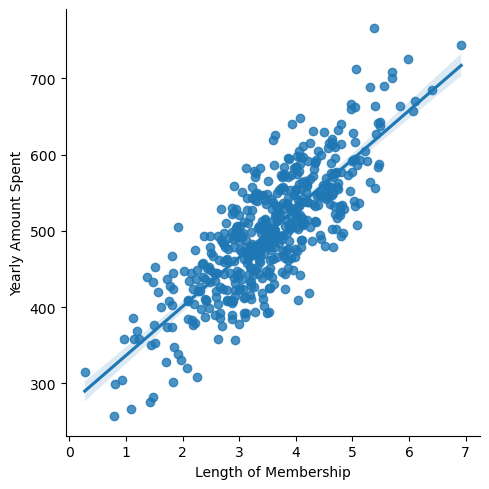

In [ ]:
# Write visualization code here
sns.lmplot(x='Length of Membership',y='Yearly Amount Spent',data=data)

- Now let's get into the machine learning part.

- Split the data into train and test sets.

> You should Keep the numeric columns only.

In [ ]:
data.drop(
    columns=['Email', 'Address', 'Avatar'],
    inplace=True
)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Time on Website       500 non-null    float64
 3   Length of Membership  500 non-null    float64
 4   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


- Now, define the features and the target.

In [ ]:
features = data.drop(columns=['Yearly Amount Spent'])
target = data['Yearly Amount Spent']

- Split the data into train and test sets with a `test_size` of 0.3.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=101)

- Import and train a linear regression model.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Print the coefficients and the intercept.

In [ ]:
model.coef_, model.intercept_

(array([25.98154972, 38.59015875,  0.19040528, 61.27909654]),
 np.float64(-1047.9327822502394))

- Make predictions and compare using scatter plot.

<Axes: xlabel='Yearly Amount Spent'>

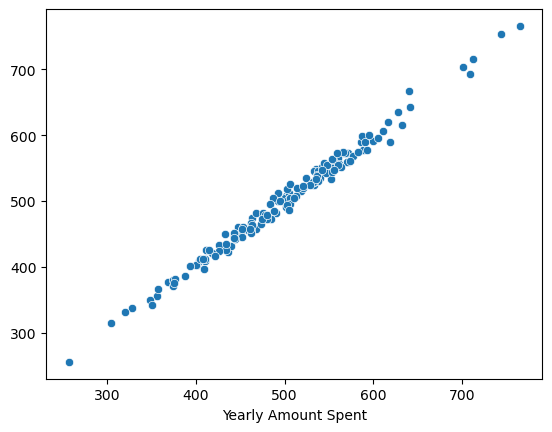

In [ ]:
predictions = model.predict(X_test)

sns.scatterplot(x=y_test, y=predictions)

- Visualise the residuals.

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

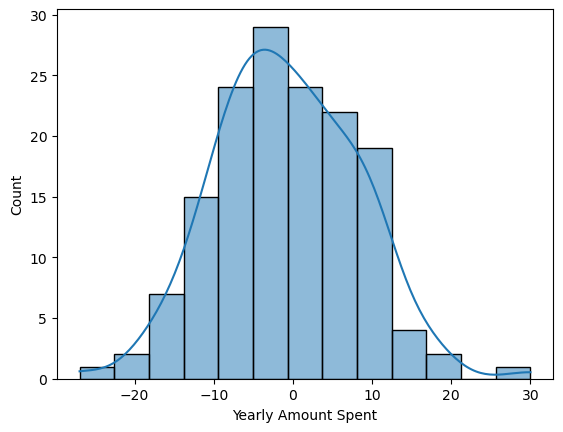

In [ ]:
sns.histplot(
    data=y_test - predictions,
    kde=True
)

Not bad! Model looks perfect for the data.

- Now, let's evaluate the model using MAE, MSE and RMSE.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f'Mean Absolute Error: {mean_absolute_error(y_test, predictions)}')
print(f'Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, predictions))}')
print(f'Mean Squared Error: {mean_squared_error(y_test, predictions)}')

Mean Absolute Error: 7.2281486534308295
Root Mean Squared Error: 8.933815066978633
Mean Squared Error: 79.81305165097444


The MAE and RMSE values are very close to each other. Which is a good sign.

Now, final task for you?

- Ditermine which features should you work on to improve the ecommerce website using the `coefficients`. Write a nice explanation in the cell below.

In [ ]:
# Make a coefficient table
pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Coefficient': model.coef_
    }
)

,Feature,Coefficient
0,Avg. Session Length,25.981550
1,Time on App,38.590159
2,Time on Website,0.190405
3,Length of Membership,61.279097


- Your answer here:

Well, Done!